# Exploration des donnees welddb : prediction de la qualite de soudures

**Projet 3IF3010 - Apprentissage automatique** - CentraleSupelec 3A Mention IA
Auteur : Jules Mortreux - branche `explo/jules`

## Objectif de ce notebook

Ce notebook est le point de depart du projet. Il ne contient volontairement
aucun modele : son seul but est de comprendre les donnees avant de les toucher.

L'enonce demande :

> *"Faire une analyse descriptive de la base de donnees pour bien la maitriser
> et identifier les taches de pre-processing pertinentes a realiser. Toute
> action de pre-processing devra etre explicitee, decrite et justifiee."*

La demarche suivie ici est donc **chronologique** : on charge le fichier
naivement, on constate les problemes, et on decide du traitement au moment ou
le probleme apparait. Le code de nettoyage reutilisable
(`src/export_processed.py`) n'est ecrit qu'ensuite, une fois les decisions
prises et justifiees, afin que les notebooks suivants travaillent sur une base
commune.

## Plan

1. Le fichier brut : a quoi on a affaire
2. Nommer les colonnes
3. Les valeurs non numeriques
4. Les valeurs manquantes
5. Les cibles candidates

## Source des donnees

`welddb` - MAP Data Library, University of Cambridge
<https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html>

Reference : T. Cool, *Design of Steel Weld Deposits*, PhD Thesis, University of
Cambridge, 1996.

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

# Racine du projet : ce notebook est dans notebooks/, les donnees dans data/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "welddb.data"
INFO = ROOT / "data" / "raw" / "welddb.info"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

print("pandas", pd.__version__)
print("donnees :", RAW.exists())
print("doc     :", INFO.exists())

pandas 2.1.4
donnees : True
doc     : True


## 1. Le fichier brut : a quoi on a affaire

Premier reflexe : ne pas charger le fichier avec pandas tout de suite.

On l'ouvre d'abord comme du texte, pour voir sa forme reelle. C'est important :
si on lance `read_csv` a l'aveugle et que ca "marche", on risque de travailler
sur des donnees mal decoupees sans s'en apercevoir.

In [2]:
# Lecture en texte brut, sans aucune interpretation.
with open(RAW, encoding="utf-8") as f:
    lignes = f.readlines()

print(f"nombre de lignes : {len(lignes)}")
print()
for i in range(3):
    print(f"--- ligne {i} ({len(lignes[i].rstrip())} caracteres) ---")
    print(lignes[i].rstrip())
    print()

nombre de lignes : 1652

--- ligne 0 (152 caracteres) ---
0.037 0.30 0.65 0.008 0.012 0 N N N N N N N N N N N N N N N 170 21 DC + 1 200 MMA 250 14 392 466 31.9 80.6 N N N N N N N N N Evans-Ni/CMn-1990/1991-0Aaw

--- ligne 1 (145 caracteres) ---
0.037 0.30 0.65 0.008 0.012 0 N N N N N N N N N N N N N N N 170 21 DC + 1 200 MMA 0 0 N N N N -28 100 N N N N N N N Evans-Ni/CMn-1990/1991-0Aawch

--- ligne 2 (155 caracteres) ---
0.037 0.30 0.65 0.008 0.012 0 N N N N N N N N N N N N N N N 170 21 DC + 1 200 MMA 580 2 370 456 35.2 80.6 -38 100 N N N N N N N Evans-Ni/CMn-1990/1991-0Aht



### Ce qu'on observe

1. **Aucune ligne d'en-tete** : la premiere ligne est deja une donnee. Les noms
   de colonnes ne sont donc pas dans ce fichier, il faudra les recuperer
   ailleurs (section 2).
2. **Separateur = espaces**, en nombre variable. Ce n'est pas un CSV a virgules,
   ni un fichier a largeur fixe.
3. **Des `N` un peu partout.** A ce stade on ne sait pas encore ce qu'ils
   signifient, c'est le premier point a elucider.
4. **La derniere colonne est du texte** (`Evans-Ni/CMn-1990/1991-0Aaw`) : ca
   ressemble a un identifiant de soudure.
5. Les 3 premieres lignes ont **les memes 5 premieres valeurs** : plusieurs
   lignes semblent decrire la meme soudure testee dans des conditions
   differentes. A verifier, car cela aurait des consequences sur le decoupage
   train/test (risque de fuite de donnees).

In [3]:
# Combien de valeurs par ligne ? Si ce n'est pas constant, le fichier est
# mal forme et il faudra traiter les lignes irregulieres.
nb_champs = pd.Series([len(l.split()) for l in lignes])

print("nombre de valeurs par ligne :")
print(nb_champs.value_counts().to_string())

nombre de valeurs par ligne :
44    1652


Toutes les lignes ont exactement 44 valeurs. Le fichier est donc regulier :
on peut le charger comme un tableau sans craindre de lignes tronquees.

In [4]:
# Chargement avec le bon separateur.
#   sep=r"\s+"   : un ou plusieurs espaces
#   header=None  : pas de ligne d'en-tete (sinon pandas prendrait la 1re donnee)
#   dtype=str    : on lit TOUT en texte volontairement.
#
# Pourquoi dtype=str ? Si on laisse pandas deviner, il va voir les "N" dans une
# colonne de nombres et basculer toute la colonne en type "object", en melangeant
# nombres et chaines. On prefere lire en texte et convertir nous-memes, en
# controlant chaque decision.
brut = pd.read_csv(RAW, sep=r"\s+", header=None, dtype=str)

print("dimensions :", brut.shape)
brut.head(3)

dimensions : (1652, 44)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
0,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,250,14,392,466,31.9,80.6,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,0,0,N,N,N,N,-28,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,580,2,370,456,35.2,80.6,-38,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aht


### Bilan de la section 1

| Constat | Consequence |
|---|---|
| **1652 lignes x 44 colonnes** | taille modeste, tout tient en memoire |
| toutes les lignes ont 44 champs | fichier regulier, chargement sur |
| pas d'en-tete | il faut nommer les colonnes (section 2) |
| separateur = espaces multiples | `sep=r"\s+"` |
| des `N` en nombre | a elucider (section 3) |
| derniere colonne textuelle | identifiant de soudure |
| lignes tres similaires entre elles | a verifier : plusieurs essais par soudure ? |

A ce stade on a un tableau, mais il est inutilisable : 44 colonnes anonymes
remplies de chaines de caracteres. La section suivante corrige le premier
point.

## 2. Nommer les colonnes

Les noms de colonnes ne sont pas dans `welddb.data`. Ils sont dans le fichier
de documentation **`welddb.info`**, livre avec les donnees.

C'est le fichier le plus important du projet a ce stade : sans lui, les 44
colonnes sont des nombres anonymes et aucune interpretation physique n'est
possible. On commence donc par le lire.

In [5]:
# Extraction automatique des descriptions depuis la documentation.
# Le fichier est structure en blocs du type :
#     Column 13
#     Oxygen concentration / parts per million by weight
texte_info = INFO.read_text(encoding="latin-1")

descriptions = dict(
    re.findall(r"Column\s+(\d+)\s*\n\s*(.+)", texte_info)
)

print(f"{len(descriptions)} descriptions de colonnes trouvees\n")
for num in range(1, 45):
    print(f"  {num:>2}. {descriptions[str(num)][:70]}")

44 descriptions de colonnes trouvees

   1. Carbon concentration / (weight%)
   2. Silicon concentration / (weight%)
   3. Manganese concentration / (weight%)
   4. Sulphur concentration / (weight%)
   5. Phosphorus concentration / (weight%)
   6. Nickel concentration / (weight%)
   7. Chromium concentration / (weight%)
   8. Molybdenum concentration / (weight%)
   9. Vanadium concentration / (weight%)
  10. Copper concentration / (weight%)
  11. Cobalt concentration / (weight%)
  12. Tungsten concentration / (weight%)
  13. Oxygen concentration / parts per million by weight
  14. Titanium concentration / parts per million by weight
  15. Nitrogen concentration / parts per million by weight
  16. Aluminium concentration / parts per million by weight
  17. Boron concentration / parts per million by weight
  18. Niobium concentration / parts per million by weight
  19. Tin concentration / parts per million by weight
  20. Arsenic concentration / parts per million by weight
  21. Antimony

### Lecture de la documentation

Les 44 colonnes se repartissent en **cinq familles**, et cette structure est la
cle de lecture du jeu de donnees :

| Colonnes | Famille | Role dans le probleme de ML |
|---|---|---|
| 1 a 21 | **Composition chimique** | entrees (X) : ce que contient le metal |
| 22 a 30 | **Parametres du procede** | entrees (X) : comment la soudure a ete realisee |
| **31 a 38** | **Proprietes mecaniques** | **sorties candidates (y)** : ce que vaut la soudure |
| 39 a 43 | **Microstructure** | sorties intermediaires (fractions de phases) |
| 44 | **Identifiant** | ni entree ni sortie |

Deux points relevent de l'analyse, pas de la simple lecture :

**Les unites ne sont pas homogenes dans la composition.** Les colonnes 1 a 12
sont en pourcentage massique (ordre de grandeur 0,01 a 2), les colonnes 13 a 21
en parties par million (ordre de grandeur 1 a 1000). Il y a donc jusqu'a
quatre ordres de grandeur d'ecart entre deux variables de meme nature. L'enonce
attire explicitement l'attention sur ce point ("reflechir aux unites de mesures
des variables, a la necessite de normaliser ou non les donnees").

**La colonne 35 n'est pas une mesure de qualite.** `Charpy temperature` est la
**temperature a laquelle l'essai de resilience a ete realise**, pas une
propriete de la soudure. Or l'acier devient cassant a froid : une tenacite de
100 J mesuree a +20 degC et la meme valeur mesuree a -60 degC ne decrivent pas
du tout la meme performance. Cette colonne doit donc etre traitee comme une
**condition d'essai** (variable explicative, ou facteur de normalisation), et
non comme une cible.

In [6]:
# Noms de colonnes, groupes par famille.
# On prefixe par l'unite quand elle est ambigue (_ppm, _pct, _MPa, _C) pour
# eviter toute erreur d'interpretation plus tard.

# Colonnes 1 a 12 : concentrations en pourcentage massique.
COMPOSITION_WT = ["C", "Si", "Mn", "S", "P", "Ni", "Cr", "Mo", "V", "Cu", "Co", "W"]

# Colonnes 13 a 21 : concentrations en parties par million.
COMPOSITION_PPM = ["O_ppm", "Ti_ppm", "N_ppm", "Al_ppm", "B_ppm",
                   "Nb_ppm", "Sn_ppm", "As_ppm", "Sb_ppm"]

# Colonnes 22 a 30 : parametres du procede de soudage.
PROCESS = ["Current_A", "Voltage_V", "AC_DC", "Electrode_pol",
           "HeatInput_kJmm", "InterpassT_C", "WeldType",
           "PWHT_T_C", "PWHT_time_h"]

# Colonnes 31 a 38 : proprietes mecaniques (cibles candidates).
MECHANICAL = ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
              "ReductionArea_pct", "CharpyT_C", "CharpyToughness_J",
              "Hardness", "FATT50"]

# Colonnes 39 a 43 : fractions de microstructure, en pourcentage.
MICROSTRUCTURE = ["PrimaryFerrite_pct", "FerriteSecondPhase_pct",
                  "AcicularFerrite_pct", "Martensite_pct",
                  "FerriteCarbide_pct"]

# Colonne 44.
IDENTIFIER = ["WeldID"]

COMPOSITION = COMPOSITION_WT + COMPOSITION_PPM
COLUMNS = COMPOSITION + PROCESS + MECHANICAL + MICROSTRUCTURE + IDENTIFIER

# Colonnes a ne jamais convertir en nombre : les trois variables categorielles
# du procede, plus l'identifiant de soudure.
CATEGORIELLES = ["AC_DC", "Electrode_pol", "WeldType"] + IDENTIFIER

print(f"{len(COLUMNS)} noms definis pour {brut.shape[1]} colonnes")
assert len(COLUMNS) == brut.shape[1], "le nombre de noms ne correspond pas"
assert len(set(COLUMNS)) == len(COLUMNS), "des noms sont dupliques"
print("verifications passees")

44 noms definis pour 44 colonnes
verifications passees


### Verification croisee

Les noms ci-dessus ont ete saisis a la main depuis la documentation. Une erreur
de decalage d'un seul cran rendrait toute l'analyse fausse sans declencher la
moindre erreur Python. On verifie donc que chaque nom correspond bien a la
description officielle de la colonne de meme rang.

In [7]:
# Table de correspondance : nom retenu <-> description officielle.
# A relire ligne par ligne, c'est le seul garde-fou contre un decalage.
correspondance = pd.DataFrame({
    "nom": COLUMNS,
    "description officielle": [descriptions[str(i + 1)] for i in range(len(COLUMNS))],
})
correspondance.index = range(1, len(COLUMNS) + 1)
correspondance.index.name = "col"
correspondance

,nom,description officielle
col,,
1,C,Carbon concentration / (weight%)
2,Si,Silicon concentration / (weight%)
3,Mn,Manganese concentration / (weight%)
4,S,Sulphur concentration / (weight%)
5,P,Phosphorus concentration / (weight%)
6,Ni,Nickel concentration / (weight%)
7,Cr,Chromium concentration / (weight%)
8,Mo,Molybdenum concentration / (weight%)
9,V,Vanadium concentration / (weight%)


In [8]:
# Application des noms. On travaille sur une copie pour garder `brut` intact :
# en exploration, pouvoir revenir aux donnees d'origine evite bien des erreurs.
df = brut.copy()
df.columns = COLUMNS

print("dimensions :", df.shape)
df.head(3)

dimensions : (1652, 44)


,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,Co,W,O_ppm,Ti_ppm,N_ppm,Al_ppm,B_ppm,Nb_ppm,Sn_ppm,As_ppm,Sb_ppm,Current_A,Voltage_V,AC_DC,Electrode_pol,HeatInput_kJmm,InterpassT_C,WeldType,PWHT_T_C,PWHT_time_h,YieldStrength_MPa,UTS_MPa,Elongation_pct,ReductionArea_pct,CharpyT_C,CharpyToughness_J,Hardness,FATT50,PrimaryFerrite_pct,FerriteSecondPhase_pct,AcicularFerrite_pct,Martensite_pct,FerriteCarbide_pct,WeldID
0,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,250,14,392,466,31.9,80.6,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,0,0,N,N,N,N,-28,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,N,N,N,N,N,N,N,N,N,N,N,170,21,DC,+,1,200,MMA,580,2,370,456,35.2,80.6,-38,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aht


Le tableau est maintenant lisible. On peut par exemple isoler les cibles
candidates et constater immediatement l'ampleur du probleme de valeurs
manquantes, qui sera traite en section 4.

In [9]:
# Apercu des cibles candidates sur les premieres lignes.
df[MECHANICAL + ["WeldID"]].head(6)

,YieldStrength_MPa,UTS_MPa,Elongation_pct,ReductionArea_pct,CharpyT_C,CharpyToughness_J,Hardness,FATT50,WeldID
0,392,466,31.9,80.6,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aaw
1,N,N,N,N,-28,100,N,N,Evans-Ni/CMn-1990/1991-0Aawch
2,370,456,35.2,80.6,-38,100,N,N,Evans-Ni/CMn-1990/1991-0Aht
3,413,498,31.2,80.6,N,N,N,N,Evans-Ni/CMn-1990/1991-0Baw
4,N,N,N,N,-48,100,N,N,Evans-Ni/CMn-1990/1991-0Bawch
5,402,490,31.0,80.6,-44,100,N,N,Evans-Ni/CMn-1990/1991-0Bht


### Bilan de la section 2

Les 44 colonnes sont nommees et verifiees une a une contre la documentation.

Trois constats structurent la suite du travail :

1. **La separation entrees / sorties est claire** : composition (21) et procede
   (9) d'un cote, proprietes mecaniques (8) de l'autre. Le probleme de ML est
   donc : predire les proprietes mecaniques a partir de la composition et du
   procede.

2. **Les unites sont heterogenes** (pourcentage massique contre ppm, jusqu'a
   quatre ordres de grandeur d'ecart). La question de la normalisation devra
   etre tranchee, et la reponse dependra de la methode employee : une ACP et un
   SVM y sont sensibles, un arbre de decision non.

3. **`CharpyT_C` est une condition d'essai, pas une cible.** Les cibles
   candidates reelles sont donc au nombre de sept, et non huit.

Le tableau reste rempli de chaines de caracteres : aucune colonne n'est encore
exploitable numeriquement. C'est l'objet de la section 3.

## 3. Les valeurs non numeriques

Le tableau est entierement constitue de chaines de caracteres, puisqu'on a
force `dtype=str` au chargement. Il faut maintenant convertir ce qui doit
l'etre, et comprendre ce qui resiste.

La methode : tenter la conversion numerique sur chaque colonne, puis
**compter et inspecter les echecs**. On ne convertit rien avant d'avoir
compris ce qu'on jette.

In [10]:
# pd.to_numeric(errors="coerce") remplace par NaN tout ce qu'il n'arrive pas a
# convertir. On compte ces echecs sans encore modifier df : c'est un diagnostic.
diagnostic = []
for col in COLUMNS:
    converti = pd.to_numeric(df[col], errors="coerce")
    echecs = int((converti.isna() & df[col].notna()).sum())
    nb_N = int((df[col] == "N").sum())
    diagnostic.append({"colonne": col, "echecs": echecs,
                       "dont 'N'": nb_N, "autres formes": echecs - nb_N})

diagnostic = pd.DataFrame(diagnostic).set_index("colonne")
diagnostic[diagnostic["echecs"] > 0]

,echecs,dont 'N',autres formes
colonne,,,
S,11,4,7
P,10,10,0
Ni,955,955,0
Cr,868,868,0
Mo,861,859,2
V,1032,724,308
Cu,1088,1074,14
Co,1544,1523,21
W,1589,1577,12


### Lecture du diagnostic

Trois situations se distinguent.

**Les colonnes reellement textuelles** (`AC_DC`, `Electrode_pol`, `WeldType`,
`WeldID`) echouent sur presque toutes les lignes : c'est normal, elles ne sont
pas censees etre numeriques. Ce sont des variables categorielles, a encoder
plus tard (one-hot encoding).

**Les colonnes dont tous les echecs sont des `N`** (par exemple `Ni`, `Cr`,
`YieldStrength_MPa`, `FATT50`) : une fois les `N` traites, la conversion
passera sans probleme.

**Les colonnes avec des "autres formes"** : c'est la colonne de droite du
tableau, et c'est elle qui demande du travail. On y trouve par exemple 419
valeurs pour `B_ppm`, 403 pour `Al_ppm`, 308 pour `V`. Ce ne sont pas des
cas marginaux.

In [11]:
# Inventaire des colonnes categorielles.
for col in ["AC_DC", "Electrode_pol", "WeldType"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())
    print()

--- AC_DC ---
AC_DC
DC    1395
N      215
AC      42

--- Electrode_pol ---
Electrode_pol
+    1451
N     156
0      38
-       7

--- WeldType ---
WeldType
MMA      1140
SA        261
FCA        87
TSA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GTAA        4
GMAA        4



Deux remarques sur ces colonnes categorielles.

`WeldType` compte dix modalites, dont certaines sont tres rares (4 occurrences
pour `SAA`, `GTAA`, `GMAA`). Il faudra decider si on les regroupe, car une
modalite a 4 instances ne permet aucune estimation fiable. La documentation
donne leur signification : `MMA` et `ShMA` designent toutes deux le soudage
manuel a l'arc, `SA` et `SMA` le soudage a l'arc submerge, ce qui suggere des
regroupements possibles.

`Electrode_pol` contient 38 valeurs `0`, alors que la documentation annonce
"electrode positive or negative". Ce `0` n'est documente nulle part : il s'agit
soit d'un codage particulier, soit d'une valeur manquante notee differemment.
A traiter comme une modalite a part entiere pour l'instant, en le signalant.

In [12]:
# Inventaire des formes non numeriques, hors "N", sur les colonnes
# censees etre numeriques.
est_un_nombre = re.compile(r"^-?\d+\.?\d*$")
colonnes_num = [c for c in COLUMNS if c not in CATEGORIELLES]

inventaire = {}
for col in colonnes_num:
    formes = sorted({v for v in df[col].dropna()
                     if v != "N" and not est_un_nombre.match(v)})
    if formes:
        inventaire[col] = formes

for col, formes in inventaire.items():
    apercu = ", ".join(formes[:6]) + (" ..." if len(formes) > 6 else "")
    print(f"{col:<22} {len(formes):>3} formes : {apercu}")

S                        1 formes : <0.002
Mo                       1 formes : <0.01
V                        4 formes : <0.0005, <0.005, <0.01, <5
Cu                       1 formes : <0.01
Co                       1 formes : <0.01
W                        1 formes : <0.1
Ti_ppm                   4 formes : <0.01, <10, <100, <5
N_ppm                    8 formes : 48tot18res, 50tot17res, 52tot18res, 54tot24res, 54totndres, 61tot34res ...
Al_ppm                   4 formes : <0.01, <100, <5, <50
B_ppm                    2 formes : <10, <5
Nb_ppm                   4 formes : <100, <5, <50, <6
Sn_ppm                   2 formes : <10, <100
As_ppm                   1 formes : <100
Sb_ppm                   2 formes : <10, <100
InterpassT_C             1 formes : 150-200
Hardness                50 formes : 143(Hv30), 144(Hv30), 153(Hv30), 154(Hv30), 155(Hv30), 157(Hv30) ...
PrimaryFerrite_pct       1 formes : <1


### Les cinq familles de valeurs non numeriques

L'inventaire ci-dessus se range en cinq categories, et chacune appelle une
decision differente.

| Famille | Exemples | Ce que cela signifie |
|---|---|---|
| `N` | `N` | la valeur n'a pas ete reportee dans la publication |
| Censure a gauche | `<0.002`, `<5`, `<100` | mesure effectuee, mais sous le seuil de detection de l'appareil |
| Unite accolee | `143(Hv30)`, `201Hv10` | la valeur et l'echelle de mesure sont collees |
| Intervalle | `150-200` | la publication donne une plage, pas une valeur |
| Total / residuel | `48tot18res` | deux mesures fusionnees dans une seule chaine |

Il est important de noter que **ces familles ne sont pas de meme nature**. Un
`N` est une absence d'information. Un `<0.002` est au contraire une information
precise : on sait que la valeur est tres petite. Les traiter de la meme facon
serait une erreur.

### Decision 1 : les valeurs `N`

La documentation officielle (`welddb.info`) est explicite :

> *"The presence of an 'N' indicates that the value was not reported in the
> publication. This is NOT meant to be an indication that the value is zero."*

| Option | Pour | Contre |
|---|---|---|
| convertir en `NaN` | fidele a la realite : l'information est absente | il faudra decider plus tard quoi en faire |
| convertir en `0` | plus aucune valeur manquante a gerer | **physiquement faux** : affirmer qu'une soudure ne contient aucun nickel alors qu'on ne l'a pas mesure |

**Decision retenue : `NaN`.** Mettre 0 reviendrait a inventer des donnees, et
biaiserait systematiquement les statistiques de composition. Le traitement des
valeurs manquantes (suppression ou imputation) est une question distincte, qui
sera traitee en section 4 apres diagnostic de leur mecanisme.

### Decision 2 : les valeurs censurees

Une valeur `<0.002` signifie : *la mesure a ete faite, le resultat est inferieur
au seuil de detection de l'instrument*. Ce n'est donc pas une valeur manquante,
c'est l'information "tres petit, mais pas necessairement nul".

Le volume concerne n'est pas negligeable : 419 valeurs pour le bore, 403 pour
l'aluminium, 308 pour le vanadium. Ce choix a donc un effet reel sur l'analyse.

| Option | Pour | Contre |
|---|---|---|
| seuil / 2 | convention usuelle en chimie analytique, conserve l'information "petit mais non nul", sans biais systematique evident | valeur conventionnelle, a assumer explicitement |
| le seuil lui-meme | majorant prudent | surestime systematiquement la concentration |
| 0 | simple | affirme l'absence totale de l'element, ce que la mesure ne dit pas |
| `NaN` | ne decide rien | **detruit une information disponible** sur plusieurs centaines de lignes |

**Decision retenue : seuil / 2.** C'est la convention la plus repandue pour les
donnees censurees a gauche en analyse chimique. Le choix est trace par le
masque construit plus bas, ce qui permettra de tester sa sensibilite (refaire
l'analyse avec une autre convention et comparer) si le temps le permet.

### Decisions 3 a 5 : les trois autres formes

**Unite accolee** (`143(Hv30)`, `201Hv10`, 58 valeurs dans `Hardness`).
On extrait la valeur numerique. L'echelle de mesure (`Hv5`, `Hv10`, `Hv30`)
correspond a des charges d'essai differentes et n'est donc pas rigoureusement
comparable d'une echelle a l'autre : on la conserve dans une colonne separee
`hardness_scale` pour pouvoir en tenir compte, ou ecarter ces lignes, en
connaissance de cause. Remarque : `Hardness` etant manquante a plus de 90 %,
cette colonne sera de toute facon difficilement exploitable.

**Intervalle** (`150-200`, 38 valeurs dans `InterpassT_C`).
On retient le milieu de l'intervalle, soit 175. C'est l'estimateur sans biais
sous hypothese de distribution uniforme sur la plage, et cela evite de perdre
38 lignes sur une colonne par ailleurs complete.

**Total / residuel** (`48tot18res`, 59 valeurs dans `N_ppm`).
La chaine contient deux mesures : l'azote total et l'azote residuel. La
documentation decrit la colonne comme "Nitrogen concentration", sans preciser
laquelle. On retient le **total**, qui est la grandeur la plus couramment
reportee et la seule presente dans toutes les variantes (certaines valeurs sont
de la forme `54totndres`, ou `nd` signale que le residuel n'a pas ete
determine).

In [13]:
# Expressions regulieres, une par famille.
RE_CENSURE = re.compile(r"^<\s*(\d+\.?\d*)$")              # <0.002
RE_INTERVALLE = re.compile(r"^(\d+\.?\d*)\s*-\s*(\d+\.?\d*)$")   # 150-200
RE_TOT_RES = re.compile(r"^(\d+\.?\d*)tot(\d+\.?\d*|nd)res$")    # 48tot18res
RE_UNITE = re.compile(r"^(\d+\.?\d*)\s*\(?\s*([A-Za-z]+\s*\d*)\s*\)?$")  # 143(Hv30)


def nettoyer_valeur(valeur, strategie_censure="moitie"):
    """Convertit une chaine brute en flottant.

    Renvoie un couple (valeur, motif), ou motif identifie le traitement
    applique. Ce motif alimente le masque de tracabilite, qui permet de
    chiffrer chaque decision de pre-traitement dans le rapport.
    """
    if valeur is None:
        return np.nan, "manquant"

    texte = str(valeur).strip()

    if texte == "" or texte.upper() == "N":
        return np.nan, "manquant"

    # Cas nominal : c'est deja un nombre.
    try:
        return float(texte), "propre"
    except ValueError:
        pass

    correspondance = RE_CENSURE.match(texte)
    if correspondance:
        seuil = float(correspondance.group(1))
        if strategie_censure == "moitie":
            return seuil / 2.0, "censure"
        if strategie_censure == "seuil":
            return seuil, "censure"
        return np.nan, "censure"

    correspondance = RE_INTERVALLE.match(texte)
    if correspondance:
        bas, haut = float(correspondance.group(1)), float(correspondance.group(2))
        return (bas + haut) / 2.0, "intervalle"

    # RE_TOT_RES doit etre teste AVANT RE_UNITE : cette derniere, plus
    # permissive, capturerait "54totndres" comme la valeur 54 suivie d'une
    # pretendue echelle "totndres". La valeur extraite serait correcte, mais le
    # motif de tracabilite serait faux.
    correspondance = RE_TOT_RES.match(texte)
    if correspondance:
        return float(correspondance.group(1)), "total_retenu"

    correspondance = RE_UNITE.match(texte)
    if correspondance:
        return float(correspondance.group(1)), "unite_retiree"

    # Forme inconnue : on ne devine pas, on signale pour traitement manuel.
    return np.nan, "non_interprete"


print("fonction definie")

fonction definie


In [14]:
# Application a toutes les colonnes numeriques, en construisant en parallele
# le masque de tracabilite.
propre = df.copy()
masque = pd.DataFrame(index=df.index, columns=df.columns, dtype=object)

# On conserve les chaines brutes de Hardness avant conversion, pour en extraire
# l'echelle de mesure.
hardness_brut = df["Hardness"].copy()

for col in COLUMNS:
    if col in CATEGORIELLES:
        serie = df[col].str.strip()
        masque[col] = np.where(serie.str.upper() == "N", "manquant", "propre")
        propre[col] = serie.replace({"N": np.nan})
        continue

    valeurs, motifs = zip(*(nettoyer_valeur(v) for v in df[col]))
    propre[col] = pd.Series(valeurs, index=df.index, dtype="float64")
    masque[col] = motifs

# Echelle de durete, conservee a part (cf. decision 3).
propre["hardness_scale"] = (
    hardness_brut.str.extract(r"\(?\s*([A-Za-z]+\s*\d*)\s*\)?$", expand=False)
    .str.replace(r"\s+", "", regex=True)
    .replace({"N": np.nan})
)

print("dimensions :", propre.shape)
print("types :")
print(propre.dtypes.value_counts().to_string())

dimensions :

 (1652, 45)
types :
float64    40
object      5


In [15]:
# Rapport de nettoyage : combien de valeurs de chaque motif, par colonne.
# Ce tableau est destine au rapport : il chiffre chaque decision.
motifs = ["propre", "manquant", "censure", "intervalle",
          "total_retenu", "unite_retiree", "non_interprete"]

rapport = pd.DataFrame({m: (masque == m).sum() for m in motifs}, index=masque.columns)

# On n'affiche que les colonnes ayant subi un traitement autre que
# "deja propre" ou "manquant".
traitees = rapport.drop(columns=["propre", "manquant"]).sum(axis=1) > 0
rapport[traitees]

,propre,manquant,censure,intervalle,total_retenu,unite_retiree,non_interprete
S,1641,4,7,0,0,0,0
Mo,791,859,2,0,0,0,0
V,620,724,308,0,0,0,0
Cu,564,1074,14,0,0,0,0
Co,108,1523,21,0,0,0,0
W,63,1577,12,0,0,0,0
Ti_ppm,865,717,70,0,0,0,0
N_ppm,1183,410,0,0,59,0,0
Al_ppm,502,747,403,0,0,0,0
B_ppm,85,1148,419,0,0,0,0


In [16]:
# Garde-fou : aucune forme ne doit rester non interpretee.
restant = int((masque == "non_interprete").sum().sum())
print(f"valeurs non interpretees : {restant}")
assert restant == 0, "des formes inconnues subsistent, a traiter avant de continuer"

# Verification que toutes les colonnes attendues numeriques le sont bien.
non_numeriques = [c for c in COLUMNS
                  if c not in CATEGORIELLES
                  and not pd.api.types.is_numeric_dtype(propre[c])]
print("colonnes numeriques non converties :", non_numeriques or "aucune")

valeurs non interpretees : 0
colonnes numeriques non converties : aucune


### Bilan de la section 3

Le tableau est maintenant exploitable : 40 colonnes numeriques, 3 colonnes
categorielles, 1 identifiant, plus la colonne `hardness_scale` derivee.

Les cinq decisions de pre-traitement prises dans cette section, avec leur
volume :

| Decision | Traitement retenu | Volume concerne |
|---|---|---|
| valeurs `N` | `NaN`, jamais 0 | 33 141 cellules, soit **45,6 % du tableau** |
| censure a gauche `<x` | seuil / 2 | 1 576 valeurs, dont 419 sur `B_ppm` |
| unite accolee | valeur extraite, echelle conservee a part | 58 valeurs sur `Hardness` |
| intervalle `a-b` | milieu de l'intervalle | 38 valeurs sur `InterpassT_C` |
| total / residuel | total retenu | 59 valeurs sur `N_ppm` |

Le masque de tracabilite (`masque`) permet de retrouver a tout moment quelles
cellules ont ete transformees et comment. C'est ce qui rend possible une
justification chiffree dans le rapport, et le test de sensibilite d'une
convention (par exemple refaire l'analyse avec `strategie_censure="seuil"` pour
verifier que les conclusions ne dependent pas de ce choix).

Un point reste entier et sera traite en section 4 : **l'ampleur des valeurs
manquantes**. Le chiffre de 45,6 % de cellules non renseignees donne la mesure
du probleme, et explique pourquoi l'enonce invite a explorer les methodes
semi-supervisees. Il faudra determiner si ces manquants sont aleatoires (MCAR),
lies aux variables observees (MAR) ou lies aux valeurs elles-memes (MNAR), car
le traitement approprie en depend entierement.

## 4. Les valeurs manquantes

45,6 % du tableau est vide. Avant de decider quoi en faire, il faut repondre a
deux questions :

1. **Ou sont-ils ?** Uniformement repartis, ou concentres sur certaines
   colonnes ?
2. **Pourquoi manquent-ils ?** C'est la question du mecanisme, et elle
   determine le traitement admissible.

Le cours distingue trois mecanismes :

| Mecanisme | Definition | Consequence |
|---|---|---|
| **MCAR** | la probabilite qu'une valeur manque ne depend de rien | suppression et imputation sont sans biais |
| **MAR** | elle depend des valeurs **observees** des autres variables | imputation possible en conditionnant sur ces variables |
| **MNAR** | elle depend des valeurs **manquantes** elles-memes | cas le plus defavorable, imputation biaisee |

Sans preuve du contraire, le cours recommande de supposer MAR. On va voir que
dans ce jeu de donnees, on peut faire mieux que supposer : le mecanisme est
identifiable.

In [17]:
# Taux de remplissage par colonne, regroupe par famille.
familles = {
    "1. composition": COMPOSITION,
    "2. procede": PROCESS,
    "3. mecanique (cibles)": MECHANICAL,
    "4. microstructure": MICROSTRUCTURE,
}

lignes = []
for nom_famille, cols in familles.items():
    for col in cols:
        lignes.append({
            "famille": nom_famille,
            "variable": col,
            "remplissage_%": round(100 * propre[col].notna().mean(), 1),
            "n_renseigne": int(propre[col].notna().sum()),
        })

completude = pd.DataFrame(lignes).sort_values(
    ["famille", "remplissage_%"], ascending=[True, False]
).reset_index(drop=True)

# Synthese par famille.
print("taux de remplissage moyen par famille :")
print(completude.groupby("famille")["remplissage_%"].mean().round(1).to_string())

taux de remplissage moyen par famille :


famille
1. composition           53.7
2. procede               94.0
3. mecanique (cibles)    36.7
4. microstructure         5.5


In [18]:
completude

,famille,variable,remplissage_%,n_renseigne
0,1. composition,C,100.0,1652
1,1. composition,Si,100.0,1652
2,1. composition,Mn,100.0,1652
3,1. composition,S,99.8,1648
4,1. composition,P,99.4,1642
5,1. composition,O_ppm,76.0,1256
6,1. composition,N_ppm,75.2,1242
7,1. composition,Ti_ppm,56.6,935
8,1. composition,V,56.2,928
9,1. composition,Al_ppm,54.8,905


### Ce que montre la completude

Les quatre familles ont des profils tres differents.

**Le procede est presque complet (96,5 % en moyenne).** `HeatInput_kJmm`,
`InterpassT_C` et `WeldType` n'ont aucune valeur manquante. C'est une bonne
nouvelle : les conditions de realisation de la soudure sont connues presque
partout.

**La composition est a moitie renseignee (53,7 %).** Mais la moyenne cache une
structure tres nette : les elements de base (`C`, `Si`, `Mn`, `S`, `P`) sont
quasi complets, alors que les elements rares (`W` 4,5 %, `Co` 7,8 %,
`As_ppm` 14,2 %) sont presque absents. Cela s'explique : une publication ne
mesure que les elements qu'elle juge pertinents pour son etude.

**Les cibles sont a 36,7 %**, et c'est le coeur du probleme du projet.

**La microstructure est a 5,5 %**, donc inexploitable comme variable. Elle
pourrait servir a interpreter quelques cas, pas a modeliser.

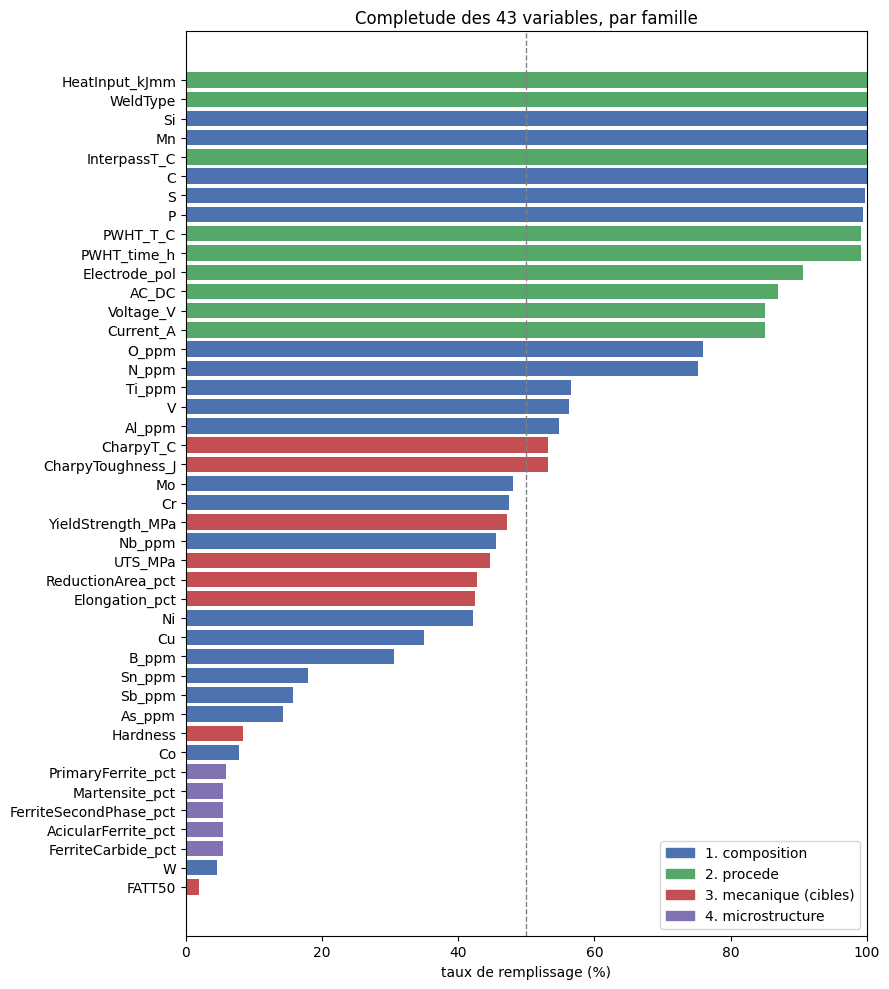

In [19]:
import matplotlib.pyplot as plt

# Convention du depot : chaque notebook ecrit ses resultats dans
# outputs/<numero>/. Le dossier figures/ est reserve aux figures finalement
# retenues pour le rapport.
OUT = ROOT / "outputs" / "01"
OUT.mkdir(parents=True, exist_ok=True)

couleurs = {"1. composition": "#4C72B0", "2. procede": "#55A868",
            "3. mecanique (cibles)": "#C44E52", "4. microstructure": "#8172B2"}

fig, ax = plt.subplots(figsize=(9, 10))
donnees = completude.sort_values("remplissage_%")
ax.barh(donnees["variable"], donnees["remplissage_%"],
        color=[couleurs[f] for f in donnees["famille"]])
ax.axvline(50, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("taux de remplissage (%)")
ax.set_title("Completude des 43 variables, par famille")
ax.set_xlim(0, 100)

poignees = [plt.Rectangle((0, 0), 1, 1, color=c) for c in couleurs.values()]
ax.legend(poignees, couleurs.keys(), loc="lower right")

plt.tight_layout()
plt.savefig(OUT / "completude_variables.png", dpi=150)
plt.show()

### Le mecanisme des manquants sur les cibles

C'est ici que l'analyse devient interessante. Plutot que de regarder les
colonnes une par une, on regarde **quelles cibles sont renseignees ensemble**
sur une meme ligne.

In [20]:
# Pour chaque ligne, quel motif de cibles renseignees ?
cibles_principales = ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
                      "ReductionArea_pct", "CharpyT_C", "CharpyToughness_J"]

presence = propre[cibles_principales].notna()
motif = presence.apply(lambda ligne: "".join("X" if v else "." for v in ligne), axis=1)

repartition = motif.value_counts().head(8).to_frame("n_lignes")
repartition["%"] = (100 * repartition["n_lignes"] / len(propre)).round(1)
repartition.index.name = "Yield UTS Elong RedA ChT ChJ"
repartition

,n_lignes,%
Yield UTS Elong RedA ChT ChJ,,
....XX,735,44.5
XXXX..,516,31.2
XXXXXX,134,8.1
......,105,6.4
X.....,40,2.4
XX....,29,1.8
X.XX..,26,1.6
.X....,23,1.4


### Interpretation : deux protocoles experimentaux

Le tableau ci-dessus est le resultat le plus important de ce notebook.

```
Yield UTS Elong RedA ChT ChJ      n
  .    .    .    .    X   X      735     essai de resilience (Charpy) seul
  X    X    X    X    .   .      516     essai de traction seul
  X    X    X    X    X   X      134     les deux essais
  .    .    .    .    .   .      105     aucune mesure
```

Les manquants ne sont pas disperses : ils forment **deux blocs quasi
disjoints**, qui correspondent aux **deux types d'essais mecaniques** :

- un **essai de traction** fournit en bloc la limite d'elasticite, la
  resistance a la traction, l'allongement et la striction ;
- un **essai Charpy** fournit la temperature d'essai et la tenacite.

Les donnees provenant de publications differentes, chaque etude a realise
l'un ou l'autre, rarement les deux. **Le mecanisme de manquance est donc le
protocole experimental de l'etude d'origine.**

Consequences directes :

1. **Ce n'est pas du MCAR.** La manquance est systematique et explicable. On
   est dans un cas de MAR structure, ou la variable explicative du manque
   (le type d'essai) n'est pas dans le tableau mais est deductible du motif
   lui-meme.

2. **Imputer une cible depuis les autres cibles est hasardeux.** Pour les 735
   lignes a Charpy seul, les quatre proprietes de traction sont absentes
   *ensemble*. Il n'y a rien a l'interieur de la ligne pour les reconstituer :
   il faudrait les predire depuis la composition, ce qui est precisement le
   probleme qu'on cherche a resoudre.

3. **Il existe deux sous-jeux exploitables** : 650 lignes avec les proprietes
   de traction, 869 avec les proprietes Charpy, dont seulement 134 en commun.
   C'est une decision de strategie majeure, a trancher en section 5.

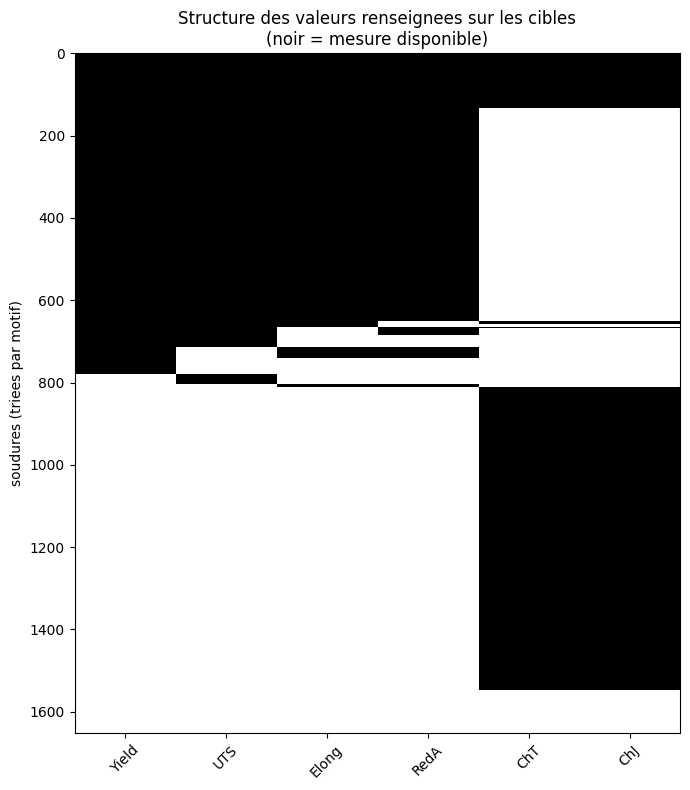

In [21]:
# Visualisation de la structure des manquants sur les cibles.
# Les lignes sont triees par motif pour faire apparaitre les blocs.
ordre = presence.sort_values(cibles_principales, ascending=False).index

fig, ax = plt.subplots(figsize=(7, 8))
ax.imshow(presence.loc[ordre].values, aspect="auto", cmap="Greys",
          interpolation="nearest")
ax.set_xticks(range(len(cibles_principales)))
ax.set_xticklabels(["Yield", "UTS", "Elong", "RedA", "ChT", "ChJ"], rotation=45)
ax.set_ylabel("soudures (triees par motif)")
ax.set_title("Structure des valeurs renseignees sur les cibles\n"
             "(noir = mesure disponible)")
plt.tight_layout()
plt.savefig(OUT / "structure_manquants_cibles.png", dpi=150)
plt.show()

La figure rend le phenomene visible : deux blocs horizontaux nets, sans
degrade. Si les manquants etaient aleatoires, on verrait un nuage de points
disperse.

### Un second point structurel : les lignes ne sont pas independantes

On avait releve en section 1 que les premieres lignes partageaient la meme
composition. Il faut le quantifier, car cela conditionne tout le protocole
d'evaluation.

In [22]:
# Combien de soudures physiquement distinctes ? On identifie une soudure par
# sa composition et ses parametres de procede hors traitement thermique
# (colonnes 1 a 28), puisque c'est le traitement thermique qui varie d'une
# ligne a l'autre pour une meme soudure.
colonnes_identite = COLUMNS[:28]

identite = df[colonnes_identite].apply(lambda ligne: "|".join(ligne.values), axis=1)
n_soudures = identite.nunique()

print(f"lignes du tableau                : {len(df)}")
print(f"soudures physiquement distinctes : {n_soudures}")
print(f"ratio                            : {len(df) / n_soudures:.1f} lignes par soudure")
print()
print("distribution du nombre de lignes par soudure :")
print(identite.value_counts().value_counts().sort_index().to_frame("n_soudures").to_string())

lignes du tableau                : 1652
soudures physiquement distinctes : 624
ratio                            : 2.6 lignes par soudure

distribution du nombre de lignes par soudure :
       n_soudures
count            
1             220
2             125
3             150
4              48
5              17
6              28
7              27
8               2
9               1
10              3
11              1
12              1
20              1


In [23]:
# Exemple concret : les trois premieres lignes du fichier.
exemple = propre.loc[:2, ["WeldID", "C", "Mn", "PWHT_T_C", "PWHT_time_h",
                          "YieldStrength_MPa", "UTS_MPa",
                          "CharpyT_C", "CharpyToughness_J"]]
exemple

,WeldID,C,Mn,PWHT_T_C,PWHT_time_h,YieldStrength_MPa,UTS_MPa,CharpyT_C,CharpyToughness_J
0,Evans-Ni/CMn-1990/1991-0Aaw,0.037,0.65,250.0,14.0,392.0,466.0,NaN,NaN
1,Evans-Ni/CMn-1990/1991-0Aawch,0.037,0.65,0.0,0.0,NaN,NaN,-28.0,100.0
2,Evans-Ni/CMn-1990/1991-0Aht,0.037,0.65,580.0,2.0,370.0,456.0,-38.0,100.0


### Ce que montre l'exemple

Les trois lignes ont la **meme composition** (`C` = 0,037, `Mn` = 0,65) mais
diffèrent par le **traitement thermique post-soudage** : 250 degC pendant 14 h,
aucun traitement, puis 580 degC pendant 2 h. Et le suffixe du `WeldID` le dit
explicitement : `aw` pour *as-welded* (brut de soudage), `ht` pour
*heat-treated* (traite thermiquement), `ch` pour *charpy*.

Il s'agit donc du **meme metal d'apport**, teste dans plusieurs etats. Les
1652 lignes correspondent a **624 soudures distinctes**, soit 2,6 lignes par
soudure en moyenne, et jusqu'a 20 pour l'une d'entre elles.

**Consequence sur l'evaluation, et elle est serieuse.** Un decoupage
train/test aleatoire placerait des lignes de la **meme** soudure a la fois dans
l'apprentissage et dans le test. Le modele aurait alors deja vu la composition
exacte des instances de test : ses performances apparaitraient bien meilleures
qu'elles ne le sont reellement. C'est une **fuite de donnees**.

La parade est de **grouper par soudure** : `GroupKFold` au lieu de `KFold`,
avec l'identifiant de soudure comme variable de groupe. L'enonce demande "un
protocole de validation croisee rigoureux" : c'est precisement de cela qu'il
s'agit.

### Bilan de la section 4

| Constat | Consequence pour la suite |
|---|---|
| 45,6 % du tableau non renseigne | une part importante du travail porte sur ce point |
| procede complet a 96,5 % | les conditions de soudage sont connues presque partout |
| elements rares quasi absents (`W` 4,5 %, `Co` 7,8 %) | ces variables devront etre ecartees |
| **manquants sur les cibles structures en deux blocs** | **MAR structure, pas MCAR ; imputation inter-cibles a eviter** |
| 650 lignes traction / 869 Charpy / 134 communes | decision de strategie a prendre (section 5) |
| **1652 lignes pour 624 soudures distinctes** | **`GroupKFold` obligatoire, sinon fuite de donnees** |

Deux decisions sont volontairement reportees, car elles dependent du choix de
la cible :

- **quel seuil de remplissage** pour conserver une variable d'entree ? Avec un
  seuil a 75 %, il reste 16 variables sur 30 ; a 50 %, il en reste 19.
- **quelle strategie d'imputation** pour les variables conservees ? Le
  diagnostic MAR autorise une imputation conditionnelle, mais le choix de la
  methode (mediane, k plus proches voisins, imputation iterative) doit etre
  compare experimentalement.

## 5. Les cibles candidates : qu'est-ce qu'une bonne soudure ?

Aucune colonne ne s'appelle "qualite". Huit proprietes mecaniques en sont des
indicateurs potentiels. Cette section cherche a comprendre ce qu'elles mesurent
et comment elles se comportent entre elles, pour pouvoir choisir la cible en
connaissance de cause.

In [24]:
# Statistiques descriptives des cibles candidates.
stats = propre[MECHANICAL].describe().T[["count", "mean", "std", "min", "50%", "max"]]
stats["count"] = stats["count"].astype(int)
stats["remplissage_%"] = (100 * stats["count"] / len(propre)).round(1)
stats.round(1)

,count,mean,std,min,50%,max,remplissage_%
YieldStrength_MPa,780,508.6,92.9,315.0,495.0,920.0,47.2
UTS_MPa,738,594.4,88.6,447.0,575.5,1151.0,44.7
Elongation_pct,700,26.3,4.9,10.6,26.8,37.0,42.4
ReductionArea_pct,705,71.8,8.9,17.0,75.0,83.0,42.7
CharpyT_C,879,-34.6,34.7,-114.0,-40.0,188.0,53.2
CharpyToughness_J,879,87.7,50.1,3.0,100.0,270.0,53.2
Hardness,138,226.9,57.7,143.0,224.0,467.0,8.4
FATT50,31,-31.1,43.6,-126.0,-15.0,30.0,1.9


### Ce que mesure chaque propriete

| Variable | Grandeur physique | Unite | Famille |
|---|---|---|---|
| `YieldStrength_MPa` | contrainte a partir de laquelle la deformation devient permanente | MPa | resistance |
| `UTS_MPa` | contrainte maximale avant rupture | MPa | resistance |
| `Hardness` | resistance a l'enfoncement | kg/mm2 | resistance |
| `Elongation_pct` | allongement avant rupture | % | ductilite |
| `ReductionArea_pct` | reduction de section avant rupture | % | ductilite |
| `CharpyToughness_J` | energie absorbee lors d'un choc | J | tenacite |
| `FATT50` | temperature de transition ductile-fragile | degC | tenacite |
| `CharpyT_C` | **temperature de l'essai de resilience** | degC | **condition d'essai** |

Deux variables sont d'emblee ecartees comme cibles :

- `Hardness` (8,4 % de remplissage) et `FATT50` (1,9 %) sont trop peu
  renseignees pour servir de cible a un modele.
- `CharpyT_C` n'est pas une propriete de la soudure mais la condition dans
  laquelle l'essai a ete mene, comme releve en section 2.

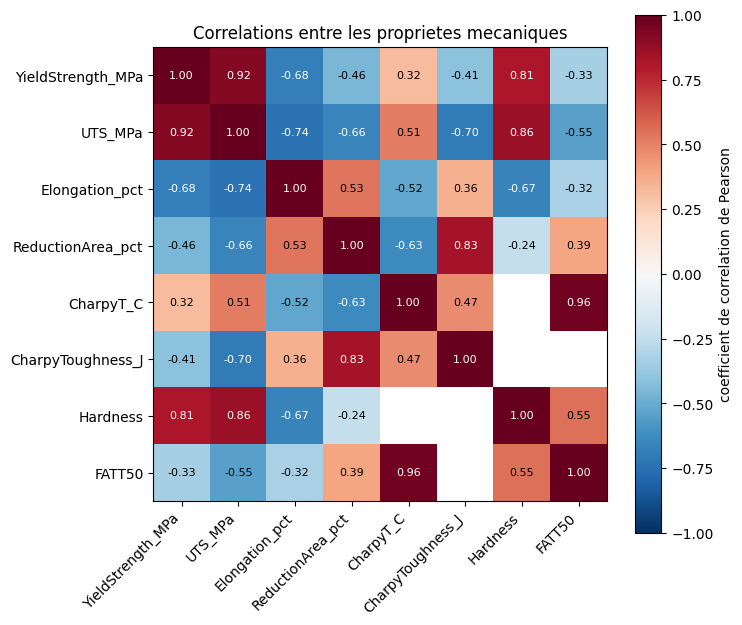

In [25]:
# Matrice de correlation entre les cibles.
# Attention : chaque coefficient est calcule sur les lignes ou LES DEUX
# variables sont renseignees. Les effectifs varient donc d'une case a l'autre,
# ce qui est a garder en tete pour l'interpretation.
correlations = propre[MECHANICAL].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
image = ax.imshow(correlations, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(MECHANICAL)))
ax.set_xticklabels(MECHANICAL, rotation=45, ha="right")
ax.set_yticks(range(len(MECHANICAL)))
ax.set_yticklabels(MECHANICAL)

for i in range(len(MECHANICAL)):
    for j in range(len(MECHANICAL)):
        valeur = correlations.iloc[i, j]
        if pd.notna(valeur):
            ax.text(j, i, f"{valeur:.2f}", ha="center", va="center",
                    fontsize=8,
                    color="white" if abs(valeur) > 0.6 else "black")

fig.colorbar(image, label="coefficient de correlation de Pearson")
ax.set_title("Correlations entre les proprietes mecaniques")
plt.tight_layout()
plt.savefig(OUT / "correlations_cibles.png", dpi=150)
plt.show()

In [26]:
# Les coefficients cles, avec l'effectif sur lequel ils sont calcules.
paires = [
    ("YieldStrength_MPa", "UTS_MPa"),
    ("Elongation_pct", "ReductionArea_pct"),
    ("UTS_MPa", "Elongation_pct"),
    ("UTS_MPa", "ReductionArea_pct"),
    ("UTS_MPa", "CharpyToughness_J"),
    ("YieldStrength_MPa", "Elongation_pct"),
]

for a, b in paires:
    commun = propre[[a, b]].dropna()
    r = commun[a].corr(commun[b])
    print(f"{a:<20} vs {b:<20} r = {r:+.3f}   (n = {len(commun)})")

YieldStrength_MPa    vs UTS_MPa              r = +0.915   (n = 714)
Elongation_pct       vs ReductionArea_pct    r = +0.535   (n = 685)
UTS_MPa              vs Elongation_pct       r = -0.739   (n = 666)
UTS_MPa              vs ReductionArea_pct    r = -0.661   (n = 671)
UTS_MPa              vs CharpyToughness_J    r = -0.702   (n = 144)
YieldStrength_MPa    vs Elongation_pct       r = -0.681   (n = 691)


### Le compromis resistance / ductilite, mesure

Les coefficients ci-dessus confirment ce que la metallurgie predit, et c'est
l'element decisif pour definir la cible.

**A l'interieur d'une meme famille, les correlations sont positives :**

```
YieldStrength vs UTS              r = +0,92     (deux mesures de resistance)
Elongation    vs ReductionArea    r = +0,54     (deux mesures de ductilite)
```

**Entre les deux familles, elles sont negatives :**

```
UTS vs Elongation                 r = -0,74
UTS vs ReductionArea              r = -0,66
UTS vs CharpyToughness            r = -0,70
YieldStrength vs Elongation       r = -0,68
```

Autrement dit : **plus une soudure est resistante, moins elle est ductile.**
C'est le compromis fondamental des aciers, et il est ici mesure, pas suppose.

**Consequence pour la definition de la cible.** Predire uniquement `UTS_MPa` et
chercher a la maximiser conduirait a recommander des soudures resistantes mais
fragiles, c'est-a-dire susceptibles de rompre brutalement sans deformation
prealable. C'est precisement le mode de defaillance le plus dangereux en
construction soudee.

Une cible representative de la "qualite" doit donc **tenir compte des deux
familles simultanement**. Cela ecarte l'option la plus simple (predire une
seule propriete) comme reponse unique.

### Quatre strategies possibles pour definir la cible

| Strategie | Principe | Avantages | Limites |
|---|---|---|---|
| **1. Une seule propriete** | predire par exemple `UTS_MPa` | simple, directement interpretable, regression classique | ignore le compromis : un modele qui maximise la resistance recommande des soudures fragiles |
| **2. Plusieurs modeles separes** | un modele par propriete, puis discussion conjointe | couvre tout, permet de comparer les difficultes de prediction | cinq modeles a entrainer, valider et rediger |
| **3. Variable composite** | construire un score combinant resistance et ductilite | repond directement a la question posee, traduit la comprehension physique | la formule de combinaison doit etre justifiee, et elle comporte une part de choix |
| **4. Approche non supervisee** | regrouper les soudures par clustering, interpreter les groupes comme des familles de qualite | exploite les lignes non etiquetees, mobilise le cours sur le clustering | pas de verite terrain, donc validation delicate |

Ces quatre pistes sont a discuter en equipe. Les correlations mesurees plus
haut suggerent que la strategie 3 est la plus fidele au probleme physique, et
que la strategie 1 peut servir de reference simple pour comparer.

Un point pratique merite d'etre souligne : une grande partie des methodes vues
en cours (SVM, classification bayesienne, k plus proches voisins) s'appliquent
a la **classification**. Discretiser la cible en classes de qualite, avec des
seuils justifies, permettrait de mobiliser ces methodes, alors qu'une cible
purement continue restreindrait le choix aux modeles de regression.

### Export des resultats de ce notebook

Avant de conclure, on enregistre les trois tableaux de synthese construits plus
haut. Ils serviront a chiffrer les decisions de pre-traitement dans le rapport,
sans avoir a reexecuter ce notebook.

In [27]:
# Les trois tableaux de synthese du notebook.
completude.to_csv(OUT / "completude_variables.csv", index=False)
rapport.to_csv(OUT / "rapport_nettoyage.csv", index_label="variable")
correlations.to_csv(OUT / "correlations_cibles.csv", index_label="variable")

# Un resume des chiffres cites dans le rapport, pour pouvoir les verifier.
resume = {
    "lignes": int(len(df)),
    "colonnes": int(len(COLUMNS)),
    "soudures_distinctes": int(n_soudures),
    "cellules_manquantes": int((masque == "manquant").sum().sum()),
    "pct_manquant": round(100 * (masque == "manquant").sum().sum() / masque.size, 1),
    "valeurs_censurees": int((masque == "censure").sum().sum()),
    "valeurs_non_interpretees": int((masque == "non_interprete").sum().sum()),
    "cibles_exploitables": ["YieldStrength_MPa", "UTS_MPa", "Elongation_pct",
                            "ReductionArea_pct", "CharpyToughness_J"],
}
(OUT / "resume_exploration.json").write_text(
    json.dumps(resume, ensure_ascii=False, indent=2), encoding="utf-8")

print("Resultats ecrits dans", OUT.relative_to(ROOT))
for chemin in sorted(OUT.iterdir()):
    print("   ", chemin.name)

Resultats ecrits dans outputs\01
    completude_variables.csv
    completude_variables.png
    correlations_cibles.csv
    correlations_cibles.png
    rapport_nettoyage.csv
    resume_exploration.json
    structure_manquants_cibles.png


## Conclusion du notebook

### Ce qui est etabli

**Sur la structure des donnees**

- 1652 lignes et 44 colonnes, dont 21 de composition chimique, 9 de procede,
  8 de proprietes mecaniques, 5 de microstructure et 1 identifiant.
- Les unites sont heterogenes : pourcentage massique pour 12 variables, parties
  par million pour 9 autres, soit jusqu'a quatre ordres de grandeur d'ecart. La
  normalisation sera necessaire pour l'ACP, les SVM et les k plus proches
  voisins, inutile pour les arbres et les forets aleatoires.
- Les 1652 lignes correspondent a **624 soudures distinctes**. L'evaluation
  devra grouper par soudure (`GroupKFold`) pour eviter une fuite de donnees.

**Sur le pre-traitement**

Cinq decisions ont ete prises et chiffrees : `N` vers `NaN` (33 141 cellules),
censure a gauche traitee par seuil/2 (1 576 valeurs), unite accolee extraite
(58), intervalle ramene a son milieu (38), total retenu pour les mesures
d'azote (59). Le masque de tracabilite permet de rejouer ces choix avec
d'autres conventions.

**Sur les valeurs manquantes**

- 45,6 % du tableau n'est pas renseigne.
- Les manquants sur les cibles sont **structures en deux blocs** correspondant
  aux deux protocoles d'essai (traction et Charpy). Le mecanisme est donc un
  MAR structure, et non du MCAR.
- La microstructure (5,5 % de remplissage) et les elements rares (`W`, `Co`,
  `As`, `Sb`, `Sn`) sont inexploitables.

**Sur la cible**

- Les cibles exploitables sont au nombre de cinq : `YieldStrength_MPa`,
  `UTS_MPa`, `Elongation_pct`, `ReductionArea_pct`, `CharpyToughness_J`.
- Elles se repartissent en deux familles **antagonistes** (resistance contre
  ductilite), avec des correlations croisees de l'ordre de -0,7. Une cible
  representative de la qualite doit en tenir compte.

### Decisions a prendre en equipe

1. **Quelle cible ?** Les quatre strategies de la section 5 sont a arbitrer.
   C'est la decision la plus structurante du projet.
2. **Regression ou classification ?** Le choix conditionne les methodes
   disponibles.
3. **Quel seuil de remplissage** pour conserver une variable d'entree ?
4. **Traiter les deux blocs d'essais separement ou ensemble ?**

### Resultats exportes

Les trois tableaux de synthese et les trois figures de ce notebook sont ecrits
dans `outputs/01/`, selon la convention du depot : chaque notebook depose ses
resultats dans `outputs/<numero>/`, et les notebooks suivants y puisent.

Le jeu de donnees nettoye lui-meme n'est pas exporte ici. Il est produit par
`src/export_processed.py`, qui reprend les regles de nettoyage etablies dans ce
notebook et ecrit `data/processed/welddb_clean.csv`, le masque de tracabilite
et les identifiants de groupe. Cette separation entre l'analyse, menee ici, et
le script de production, appele par les notebooks suivants, evite de
reexecuter l'ensemble de l'exploration a chaque fois. Elle a toutefois
l'inconvenient de faire exister les regles de nettoyage en deux endroits, ce
qui est a resoudre avant le rendu final.

### Suite du travail

La chaine de traitement construite par l'equipe a partir de ce notebook :

- **notebook 02** : construction et justification de la cible, un score de
  compromis entre resistance et ductilite
- **notebook 03** : preparation des entrees, valeurs manquantes et encodage
- **notebook 04** : analyse en composantes principales, pour developper
  l'intuition sur la structure des donnees comme demande par l'enonce
- **notebook 05** : modeles a base d'arbres, bagging et forets aleatoires
- **notebook 06** : modeles lineaires penalises, regression apres ACP et k plus
  proches voisins
- **notebook 07** : K-means, regroupement sans la cible

Restent a traiter : une methode semi-supervisee pour exploiter les lignes sans
mesure mecanique, l'importance des variables pour repondre a la question des
recommandations, et un modele de boosting, famille au programme du cours et
absente a ce stade.